# Dipole deconvolution + denoising restoration

0. 조교가 만든 A. end to end UNet network의 체크포인트를 제공해 드리오니, 필요 시 활용하셔도 됩니다.

1. dataset 폴더의 **test_deconv_noise** 데이터를 모델의 input으로 넣어서, **test_label(정답)** 데이터를 이용해 metric을 측정해 주세요.
test_deconv_noise dataset은 dipole conv --> noise 순서로 만들어 졌습니다.

2. metric을 측정을 위해 이전에 제공한 **psnr, ssim** 코드를 사용해 주세요.

**결과 분석 & 좋은 점수를 위한 tips...**
- test_deconv_noise/noise_meta.json 에서 각각의 이미지가 어떤 노이즈에 해당하는지 확인하실 수 있습니다. 결과 분석에만 사용해 주세요.

- train을 위해서 사용한 synthetic image, 결과 test 이미지는 꼭 visaulize 해 보세요. difference map, detail한 부분은 zoom-in을 해 주세요.

- 구축한 프레임워크가 어떤 노이즈에 취약한지, 어떤 type의 이미지에 취약한지 분석해 보세요.

- Day1, Day2 때 했던 conventional methods 들과 결과를 비교해 보세요.

- 적은 수의 데이터로 학습하기 or self supervised learning 방식을 활용해 보세요.

## 1. Forward model : dipole convolution + noise

$$y = \mathcal{N}\big(\underbrace{\mathcal{F}^{-1}\{D(k)\,\mathcal{F}\{x\}\}}_{\text{dipole convolution}}\big)$$

- `train` / `val` : clean image에 ** dipole + noise** 를 건다.
  - train 은 flip augmentation 후 매번 새 noise
  - val 은 파일 이름 기반 seed 로 noise 를 고정해 epoch 간 비교가 가능하게 한다
- `test` : 제공된 **`test_deconv_noise`**


### 1-1. Dipole kernel

$$D(k) = \frac{1}{3} - \frac{(k \cdot \hat{B_0})^2}{|k|^2}$$

`B0_dir = (0, 1)` -> magic angle (약 54.7도) 원뿔에서 `D = 0` 이라 그 성분은 원리적으로 복원 불가능하다.

In [ ]:
@lru_cache(maxsize=16)
def dipole_kernel(
    matrix_size: tuple[int, int],
    voxel_size: tuple[float, float] = VOXEL_SIZE,
    B0_dir: tuple[float, float] = B0_DIR,
) -> torch.Tensor:
    y = np.arange(-matrix_size[1] / 2, matrix_size[1] / 2, 1)
    x = np.arange(-matrix_size[0] / 2, matrix_size[0] / 2, 1)
    Y, X = np.meshgrid(y, x)

    X = X / (matrix_size[0] * voxel_size[0])
    Y = Y / (matrix_size[1] * voxel_size[1])

    D = 1 / 3 - (X * B0_dir[0] + Y * B0_dir[1]) ** 2 / (X**2 + Y**2 + 1e-8)
    D = np.fft.fftshift(D)
    return torch.tensor(D, dtype=torch.float32)


def dipole_forward(img: Tensor) -> Tensor:
    kernel = dipole_kernel(tuple(img.shape[-2:])).to(img.device)
    img_k = torch.fft.fftn(img, dim=(-2, -1))
    return torch.fft.ifftn(img_k * kernel, dim=(-2, -1)).real


dipole_adjoint = dipole_forward  # A^T = A (D 가 real, even)

_D = dipole_kernel((256, 256))
print(f"D range [{_D.min():.4f}, {_D.max():.4f}] | |D| < 0.01 인 비율 {float((_D.abs() < 0.01).float().mean()) * 100:.2f}%")

### 1-2. Noise 4종 (Gaussian, Rician, Uniform, Salt and Pepper)

    "gaussian": (0.0, 0.1),
    "rician": (0.0, 0.15),
    "uniform": (0.0, 0.2),
    "salt_and_pepper": (0.0, 0.2)

In [ ]:
class NoisyType(str, Enum):
    Gaussian = "gaussian"
    Rician = "rician"
    Uniform = "uniform"
    SaltAndPepper = "salt_and_pepper"

    @classmethod
    def from_string(cls, value: str) -> "NoisyType":
        try:
            return cls(value)
        except ValueError as err:
            raise ValueError(f"Invalid NoisyType value: {value}. Must be one of {list(cls)} : {err}") from err

Gen = torch.Generator | None


def gaussian_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    noise = torch.empty_like(img).normal_(0.0, 1.0, generator=generator) * sigma
    return img + noise


def rician_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    noise_real = torch.empty_like(img).normal_(0.0, 1.0, generator=generator) * sigma
    noise_imag = torch.empty_like(img).normal_(0.0, 1.0, generator=generator) * sigma
    return torch.abs(img + noise_real + 1j * noise_imag)


def uniform_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    return img + (torch.empty_like(img).uniform_(0.0, 1.0, generator=generator) * 2.0 - 1.0) * sigma


def salt_and_pepper_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    salt_prob = sigma / 2
    pepper_prob = sigma / 2
    noisy_img = img.clone()
    total_pixels = img.numel()

    num_salt = int(total_pixels * salt_prob)
    coords = [torch.randint(0, dim, (num_salt,), generator=generator) for dim in img.shape]
    noisy_img[tuple(coords)] = img.max()

    num_pepper = int(total_pixels * pepper_prob)
    coords = [torch.randint(0, dim, (num_pepper,), generator=generator) for dim in img.shape]
    noisy_img[tuple(coords)] = 0

    return noisy_img


NOISE_FUNC: dict[NoisyType, Callable[..., Tensor]] = {
    NoisyType.Gaussian: gaussian_noise,
    NoisyType.Rician: rician_noise,
    NoisyType.Uniform: uniform_noise,
    NoisyType.SaltAndPepper: salt_and_pepper_noise,
}


class NoiseSimulator:
    """noise 종류 하나 + sigma 하나를 고정해서 적용한다."""

    def __init__(self, noisy_type: NoisyType, sigma: float) -> None:
        self.noisy_type = noisy_type
        self.sigma = sigma

    def __call__(self, img: Tensor, generator: Gen = None) -> Tensor:
        return NOISE_FUNC[self.noisy_type](img, self.sigma, generator)


class RandomNoiseSimulator:
    """이미지마다 4종 중 하나를 랜덤으로 골라 NOISE_RANGES 범위에서 sigma 를 뽑는다."""

    def __init__(self, noise_ranges: dict[str, tuple[float, float]] | None = None) -> None:
        self.noise_ranges = dict(noise_ranges) if noise_ranges is not None else dict(NOISE_RANGES)
        self.names = list(self.noise_ranges.keys())

    def _sample(self, rng) -> tuple[str, float]:
        name = rng.choice(self.names)
        low, high = self.noise_ranges[name]
        return name, rng.uniform(low, high)

    def __call__(self, img: Tensor, seed: int | None = None) -> Tensor:
        if seed is None:
            # 학습용: 매번 새로 뽑는다 (같은 이미지도 epoch 마다 다른 노이즈)
            name, sigma = self._sample(random)
            generator = None
        else:
            # 검증용: 이미지마다 항상 같은 노이즈가 나오도록 seed 를 고정한다.
            name, sigma = self._sample(random.Random(seed))
            generator = torch.Generator().manual_seed(int(seed) % (2**63 - 1))
        return NoiseSimulator(NoisyType.from_string(name), sigma)(img, generator)

    def describe(self, seed: int) -> tuple[str, float]:
        return self._sample(random.Random(seed))


class DegradationSimulator:
    """clean image -> (blur, measure, noisy_label).

    - blur        : noise 없는 dipole 결과 A x
    - measure     : 실제 측정 N(A x)          <- dipole + noise
    - noisy_label : N(x)                      <- dipole 없이 noise 만 (DnCNN augmentation 용)
    """

    def __init__(self, noise_ranges: dict[str, tuple[float, float]] | None = None) -> None:
        self.noise = RandomNoiseSimulator(noise_ranges)

    def __call__(self, label: Tensor, seed: int | None = None) -> tuple[Tensor, Tensor, Tensor]:
        blur = dipole_forward(label)
        measure = self.noise(blur, seed=seed)
        # clean branch 는 dipole branch 와 독립적인 noise 를 뽑는다 (seed 는 겹치지 않게 어긋냄)
        noisy_label = self.noise(label, seed=None if seed is None else seed ^ 0x5BF03635)
        return blur, measure, noisy_label

## 2. Metric (PSNR / SSIM)

In [ ]:
IMG_DIM: int = 4


class SSIMcal(torch.nn.Module):
    def __init__(self, win_size: int = 11, k1: float = 0.01, k2: float = 0.03):
        super().__init__()
        self.win_size = win_size
        self.k1, self.k2 = k1, k2
        self.register_buffer("w", torch.ones(1, 1, win_size, win_size) / win_size**2)
        np_ = win_size**2
        self.cov_norm = np_ / (np_ - 1)

    def forward(self, img: Tensor, ref: Tensor, data_range: Tensor) -> Tensor:
        data_range = data_range[:, None, None, None]
        C1 = (self.k1 * data_range) ** 2
        C2 = (self.k2 * data_range) ** 2

        w = self.w.to(img.device)
        ux = functional.conv2d(img, w)
        uy = functional.conv2d(ref, w)
        uxx = functional.conv2d(img * img, w)
        uyy = functional.conv2d(ref * ref, w)
        uxy = functional.conv2d(img * ref, w)

        vx = self.cov_norm * (uxx - ux * ux)
        vy = self.cov_norm * (uyy - uy * uy)
        vxy = self.cov_norm * (uxy - ux * uy)

        A1 = 2 * ux * uy + C1
        A2 = 2 * vxy + C2
        B1 = ux**2 + uy**2 + C1
        B2 = vx + vy + C2

        return torch.mean((A1 * A2) / (B1 * B2), dim=[2, 3], keepdim=True)


ssim_cal = SSIMcal()


def calculate_ssim(img: Tensor, ref: Tensor, mask: Tensor | None = None) -> Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is None:
        img_mask, ref_mask = img, ref
    else:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")
        img_mask, ref_mask = img * mask, ref * mask

    ones = torch.ones(ref.shape[0], device=ref.device)
    return ssim_cal.forward(img_mask, ref_mask, ones)


def calculate_psnr(img: Tensor, ref: Tensor, mask: Tensor | None = None) -> Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is not None:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")
        img_mask, ref_mask = img * mask, ref * mask
        mse = torch.sum((img_mask - ref_mask) ** 2, dim=(1, 2, 3)) / torch.sum(mask, dim=(1, 2, 3))
    else:
        mse = torch.mean(functional.mse_loss(img, ref, reduction="none"), dim=(1, 2, 3), keepdim=True)

    img_max = torch.amax(ref, dim=(1, 2, 3), keepdim=True)
    return 10 * torch.log10(img_max**2 / (mse + 1e-12))


def finalize(pred: Tensor) -> Tensor:
    """모든 방법에 동일하게 적용하는 후처리. label 이 [0,1] 이므로 clip 한다."""
    return pred.clamp(0.0, 1.0) if config.clip_output else pred


def psnr_ssim_np(img: np.ndarray, ref: np.ndarray) -> tuple[float, float]:
    def _t(arr: np.ndarray) -> Tensor:
        return torch.from_numpy(np.ascontiguousarray(arr)).float()[None, None]

    _img, _ref = _t(img), _t(ref)
    return float(calculate_psnr(_img, _ref).item()), float(calculate_ssim(_img, _ref).mean().item())

### 2-1. Train synthetic pair 확인

`train` split 은 매 epoch 새로 noise 를 뽑으므로, 같은 영상이라도 매번 다른 degradation 이 걸린다.

train dataset length: 7268
  gaussian         sigma 0.0 ~ 0.1
  rician           sigma 0.0 ~ 0.15
  uniform          sigma 0.0 ~ 0.2
  salt_and_pepper  sigma 0.0 ~ 0.2
label   : (6, 1, 256, 256) range [0.000, 1.000]
measure : (6, 1, 256, 256) range [-0.532, 0.664]


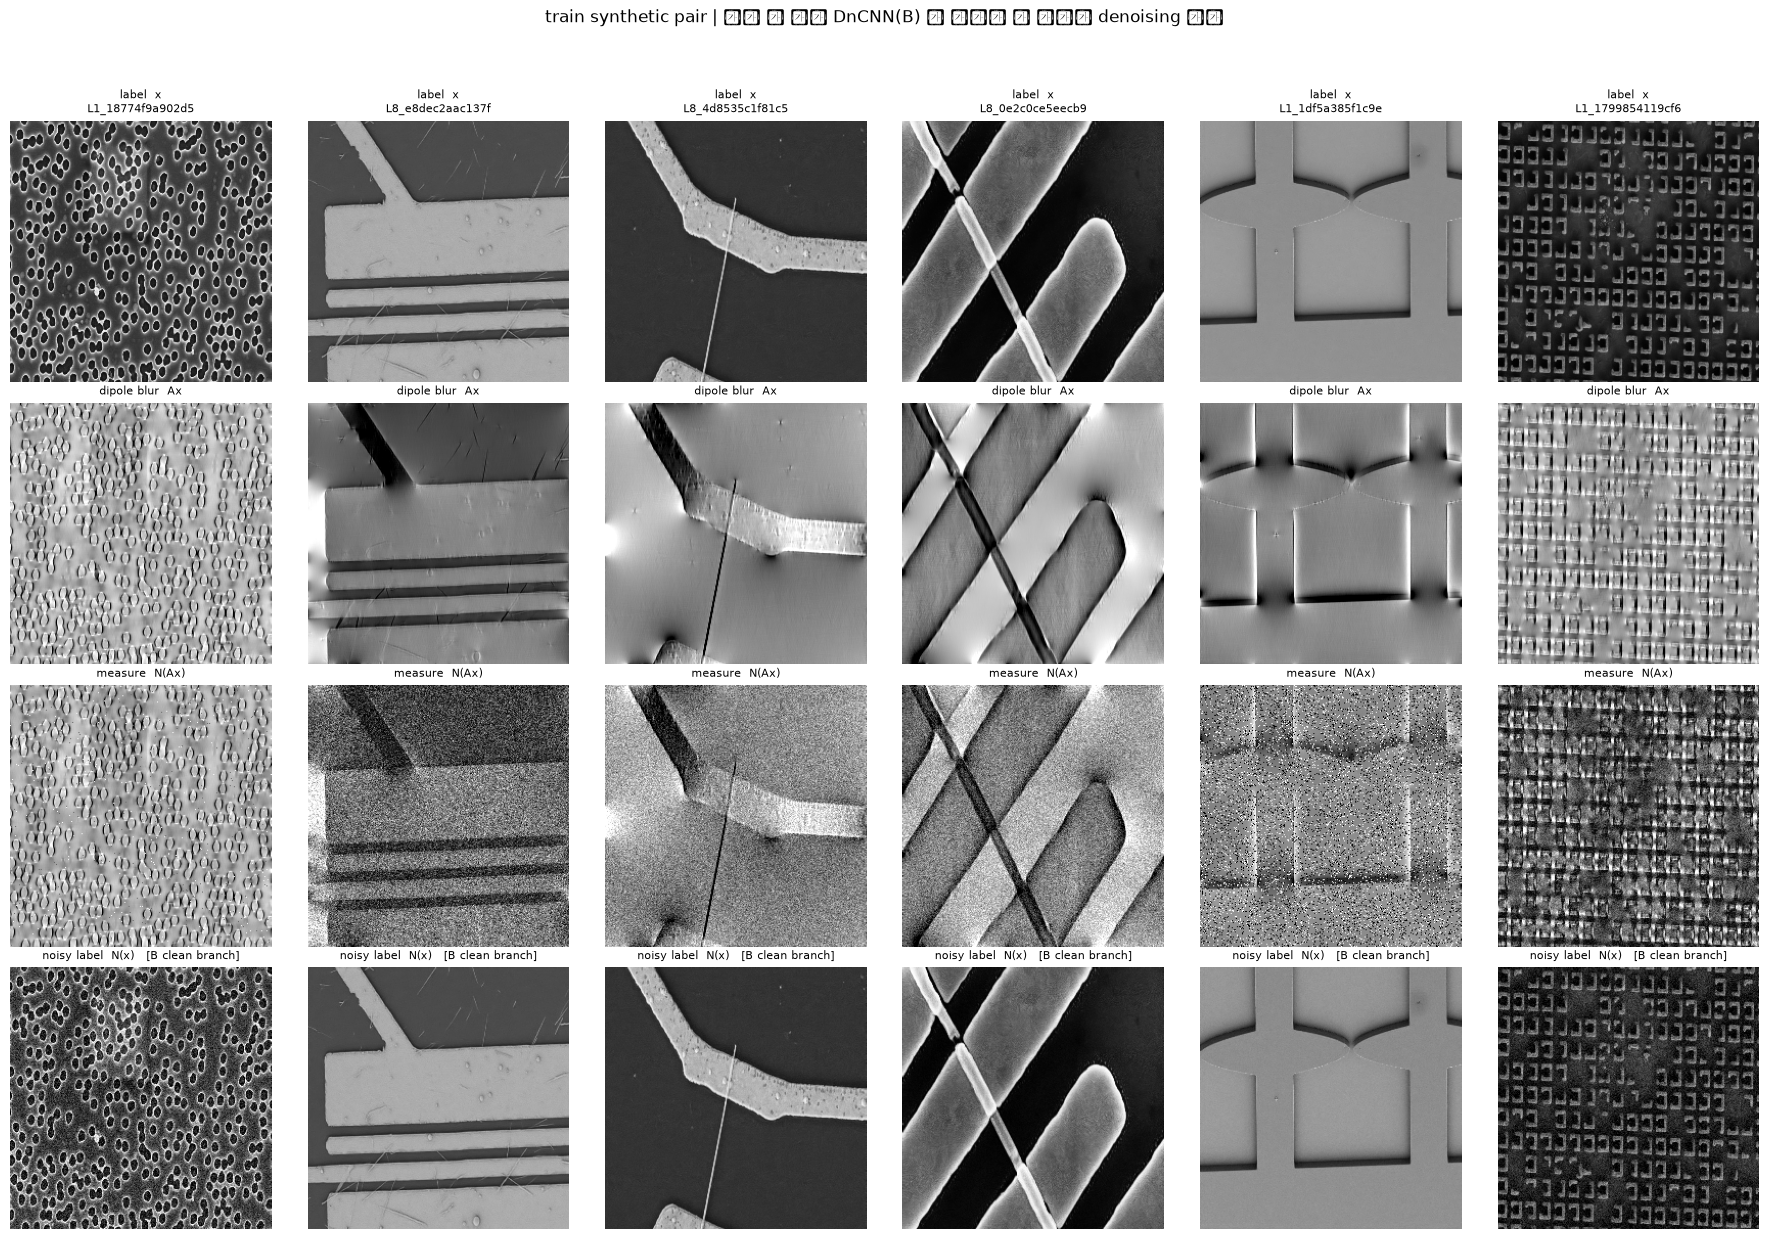

In [ ]:
_train_loader, _, _train_len = get_data_wrapper_loader(
    label_split=config.train_split,
    training_mode=True,
    loader_cfg=LoaderConfig(batch=6, num_workers=0, shuffle=True),
)
print(f"train dataset length: {_train_len}")
for k, v in NOISE_RANGES.items():
    print(f"  {k:16s} sigma {v[0]} ~ {v[1]}")

_l, _m, _b, _nl, _n = next(iter(_train_loader))
print(f"label   : {tuple(_l.shape)} range [{_l.min():.3f}, {_l.max():.3f}]")
print(f"measure : {tuple(_m.shape)} range [{_m.min():.3f}, {_m.max():.3f}]")

n = _l.shape[0]
fig, axes = plt.subplots(4, n, figsize=(3 * n, 12.6))
for i in range(n):
    axes[0, i].imshow(_l[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"label  x\n{_n[i][:16]}", fontsize=8)
    _bb = _b[i, 0].numpy()
    axes[1, i].imshow(_bb, cmap="gray", vmin=np.percentile(_bb, 1), vmax=np.percentile(_bb, 99))
    axes[1, i].set_title("dipole blur  Ax", fontsize=8)
    _mm = _m[i, 0].numpy()
    axes[2, i].imshow(_mm, cmap="gray", vmin=np.percentile(_mm, 1), vmax=np.percentile(_mm, 99))
    axes[2, i].set_title("measure  N(Ax)", fontsize=8)
    axes[3, i].imshow(_nl[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[3, i].set_title("noisy label  N(x)   [B clean branch]", fontsize=8)
    for r in range(4):
        axes[r, i].axis("off")
fig.suptitle("train synthetic pair | 아래 두 줄이 DnCNN(B) 이 배우는 두 종류의 denoising 입력")
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

del _train_loader

## 3. Conventional methods : mean / median / adaptive filter + Wiener filter

학습 없이, forward model (`dipole_kernel`) 을 안다는 가정만으로 복원한다.

1. **denoise** : mean / median / adaptive filter
2. **deconvolve** : Wiener filter
   $$\hat{x} = \mathcal{F}^{-1}\Big\{\frac{D}{D^2 + K}\,\mathcal{F}\{y\}\Big\}$$
   `K` 는 validation set 에서 PSNR 이 최대가 되도록 sweep 해서 고른다.

In [ ]:
def _as_bchw(img: Tensor) -> tuple[Tensor, int]:
    dim = img.dim()
    if dim == 2:
        return img[None, None], dim
    if dim == 3:
        return img[None], dim
    if dim == 4:
        return img, dim
    raise ValueError(f"unsupported image dim: {dim}")


def _restore_dim(img: Tensor, dim: int) -> Tensor:
    if dim == 2:
        return img[0, 0]
    if dim == 3:
        return img[0]
    return img


def mean_filter(img: Tensor, kernel_size: int = 3) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    x = functional.pad(x, (pad, pad, pad, pad), mode="reflect")
    return _restore_dim(functional.avg_pool2d(x, kernel_size=kernel_size, stride=1), dim)


def median_filter(img: Tensor, kernel_size: int = 3) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    x = functional.pad(x, (pad, pad, pad, pad), mode="reflect")
    patches = x.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    out = patches.reshape(*patches.shape[:4], -1).median(dim=-1).values
    return _restore_dim(out, dim)


def adaptive_filter(img: Tensor, kernel_size: int = 5, noise_var: Tensor | float | None = None) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    xp = functional.pad(x, (pad, pad, pad, pad), mode="reflect")

    local_mean = functional.avg_pool2d(xp, kernel_size=kernel_size, stride=1)
    local_sq = functional.avg_pool2d(xp.pow(2), kernel_size=kernel_size, stride=1)
    local_var = (local_sq - local_mean.pow(2)).clamp_min(0.0)

    if noise_var is None:
        noise_var = local_var.flatten(2).median(dim=-1).values[:, :, None, None]

    ratio = (noise_var / local_var.clamp_min(1e-8)).clamp(max=1.0)
    return _restore_dim(x - ratio * (x - local_mean), dim)


def wiener_deconv(img: Tensor, K: float) -> Tensor:
    """(1/D) * D^2/(D^2 + K) = D / (D^2 + K). D 가 실수라 0 나눗셈 없이 바로 쓸 수 있다."""
    kernel = dipole_kernel(tuple(img.shape[-2:])).to(img.device)
    w = kernel / (kernel**2 + K)
    img_k = torch.fft.fftn(img, dim=(-2, -1))
    return torch.fft.ifftn(img_k * w, dim=(-2, -1)).real


def tkd(img: Tensor, clip: float = 5.0) -> Tensor:
    kernel = dipole_kernel(tuple(img.shape[-2:])).to(img.device)
    kernel_inv = torch.clip(1 / kernel, min=-clip, max=clip)
    img_k = torch.fft.fftn(img, dim=(-2, -1))
    return torch.fft.ifftn(img_k * kernel_inv, dim=(-2, -1)).real


BASELINE_KERNEL: int = 3
ADAPTIVE_KERNEL: int = 5

PREFILTERS: dict[str, Callable[[Tensor], Tensor]] = {
    "none": lambda x: x,
    "mean": lambda x: mean_filter(x, kernel_size=BASELINE_KERNEL),
    "median": lambda x: median_filter(x, kernel_size=BASELINE_KERNEL),
    "adaptive": lambda x: adaptive_filter(x, kernel_size=ADAPTIVE_KERNEL),
}
PREFILTER_LABEL: dict[str, str] = {
    "none": "Wiener only",
    "mean": f"Mean {BASELINE_KERNEL}x{BASELINE_KERNEL} + Wiener",
    "median": f"Median {BASELINE_KERNEL}x{BASELINE_KERNEL} + Wiener",
    "adaptive": f"Adaptive {ADAPTIVE_KERNEL}x{ADAPTIVE_KERNEL} + Wiener",
}

### 3-1. Validation set 으로 Wiener `K` 튜닝

valid images: 100
Wiener only                        best K = 0.01778  (valid PSNR 14.899 dB, 0.5s)
Mean 3x3 + Wiener                  best K = 0.005623  (valid PSNR 18.854 dB, 0.4s)
Median 3x3 + Wiener                best K = 0.005623  (valid PSNR 18.814 dB, 0.4s)
Adaptive 5x5 + Wiener              best K = 0.01  (valid PSNR 18.793 dB, 0.4s)


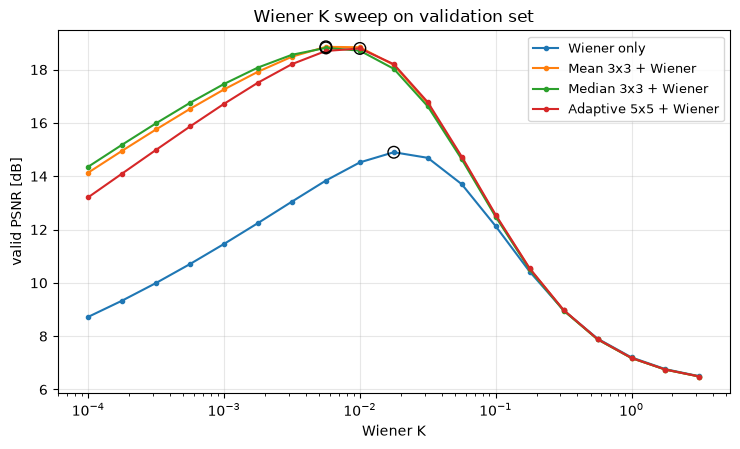

In [ ]:
WIENER_K_GRID: list[float] = [float(k) for k in np.logspace(-4, 0.5, 19)]

valid_loader, valid_dataset, valid_len = get_data_wrapper_loader(
    label_split=config.valid_split,
    training_mode=False,
    loader_cfg=LoaderConfig(batch=config.valid_batch, num_workers=4, shuffle=False),
)
print(f"valid images: {valid_len}")


def sweep_wiener_K(
    loader: DataLoader,
    pre: Callable[[Tensor], Tensor],
    k_grid: list[float],
    device: torch.device,
) -> tuple[float, dict[float, float]]:
    """loader 전체에 대해 K 별 평균 PSNR 을 재고, 최대가 되는 K 를 돌려준다."""
    acc: dict[float, list[float]] = {k: [] for k in k_grid}
    with torch.no_grad():
        for _data in loader:
            label = _data[DataKey.Label].to(device, non_blocking=True)
            measure = _data[DataKey.Measure].to(device, non_blocking=True)
            filtered = pre(measure)
            for k in k_grid:
                pred = finalize(wiener_deconv(filtered, K=k))
                acc[k].extend(calculate_psnr(pred, label).flatten().tolist())
    mean_psnr = {k: float(np.mean(v)) for k, v in acc.items()}
    best_k = max(mean_psnr, key=mean_psnr.get)
    return best_k, mean_psnr


BEST_K: dict[str, float] = {}
K_CURVES: dict[str, dict[float, float]] = {}

for _key, _fn in PREFILTERS.items():
    t0 = time.time()
    _best, _curve = sweep_wiener_K(valid_loader, _fn, WIENER_K_GRID, config.device)
    BEST_K[_key] = _best
    K_CURVES[_key] = _curve
    print(f"{PREFILTER_LABEL[_key]:<34} best K = {_best:.4g}  (valid PSNR {_curve[_best]:.3f} dB, {time.time() - t0:.1f}s)")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for _key in PREFILTERS:
    _curve = K_CURVES[_key]
    ax.semilogx(list(_curve.keys()), list(_curve.values()), marker="o", ms=3, label=PREFILTER_LABEL[_key])
    ax.scatter([BEST_K[_key]], [_curve[BEST_K[_key]]], s=70, zorder=5, facecolors="none", edgecolors="k")
ax.set_xlabel("Wiener K")
ax.set_ylabel("valid PSNR [dB]")
ax.set_title("Wiener K sweep on validation set")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 3-2. Test set 에서 conventional methods results

In [ ]:
def conventional_predict(measure: Tensor) -> dict[str, Tensor]:
    """튜닝된 K 로 conventional 결과를 한 번에 만든다."""
    out = {"measure": finalize(measure)}
    for key, fn in PREFILTERS.items():
        out[f"conv_{key}"] = finalize(wiener_deconv(fn(measure), K=BEST_K[key]))
    return out


CONV_METHODS: list[str] = ["measure", *[f"conv_{k}" for k in PREFILTERS]]
CONV_LABEL: dict[str, str] = {"measure": "Measure (input)", **{f"conv_{k}": v for k, v in PREFILTER_LABEL.items()}}

conv_rows: list[dict] = []
with torch.no_grad():
    for _data in tqdm(test_loader, desc="conventional", unit="batch"):
        label = _data[DataKey.Label].to(config.device)
        measure = _data[DataKey.Measure].to(config.device)
        names = _data[DataKey.Name]

        preds = conventional_predict(measure)
        for i in range(label.shape[0]):
            lab_i = label[i : i + 1]
            row = {"file": names[i], "noise_type": TEST_NOISE_META.get(names[i], {}).get("noise_type", "unknown")}
            for key in CONV_METHODS:
                p = preds[key][i : i + 1]
                row[f"psnr_{key}"] = calculate_psnr(p, lab_i).item()
                row[f"ssim_{key}"] = calculate_ssim(p, lab_i).item()
            conv_rows.append(row)


def print_metric_table(rows: list[dict], methods: list[str], labels: dict[str, str], width: int = 34) -> None:
    print(f"{'method':<{width}}{'n':>5}{'PSNR':>10}{'+-':>9}{'SSIM':>10}{'+-':>9}")
    print("-" * (width + 43))
    for key in methods:
        psnr = [r[f"psnr_{key}"] for r in rows]
        ssim = [r[f"ssim_{key}"] for r in rows]
        print(
            f"{labels[key]:<{width}}{len(rows):>5}"
            f"{np.mean(psnr):>10.3f}{np.std(psnr, ddof=1):>9.3f}"
            f"{np.mean(ssim):>10.4f}{np.std(ssim, ddof=1):>9.4f}"
        )


print()
print_metric_table(conv_rows, CONV_METHODS, CONV_LABEL)

conventional:   0%|          | 0/100 [00:00<?, ?batch/s]


method                                n      PSNR       +-      SSIM       +-
-----------------------------------------------------------------------------
Measure (input)                     100     8.161    2.002   -0.0143   0.1460
Wiener only                         100    15.228    3.965    0.4146   0.2540
Mean 3x3 + Wiener                   100    19.256    4.186    0.5296   0.2134
Median 3x3 + Wiener                 100    19.288    5.029    0.5453   0.2553
Adaptive 5x5 + Wiener               100    19.088    3.721    0.5512   0.2053


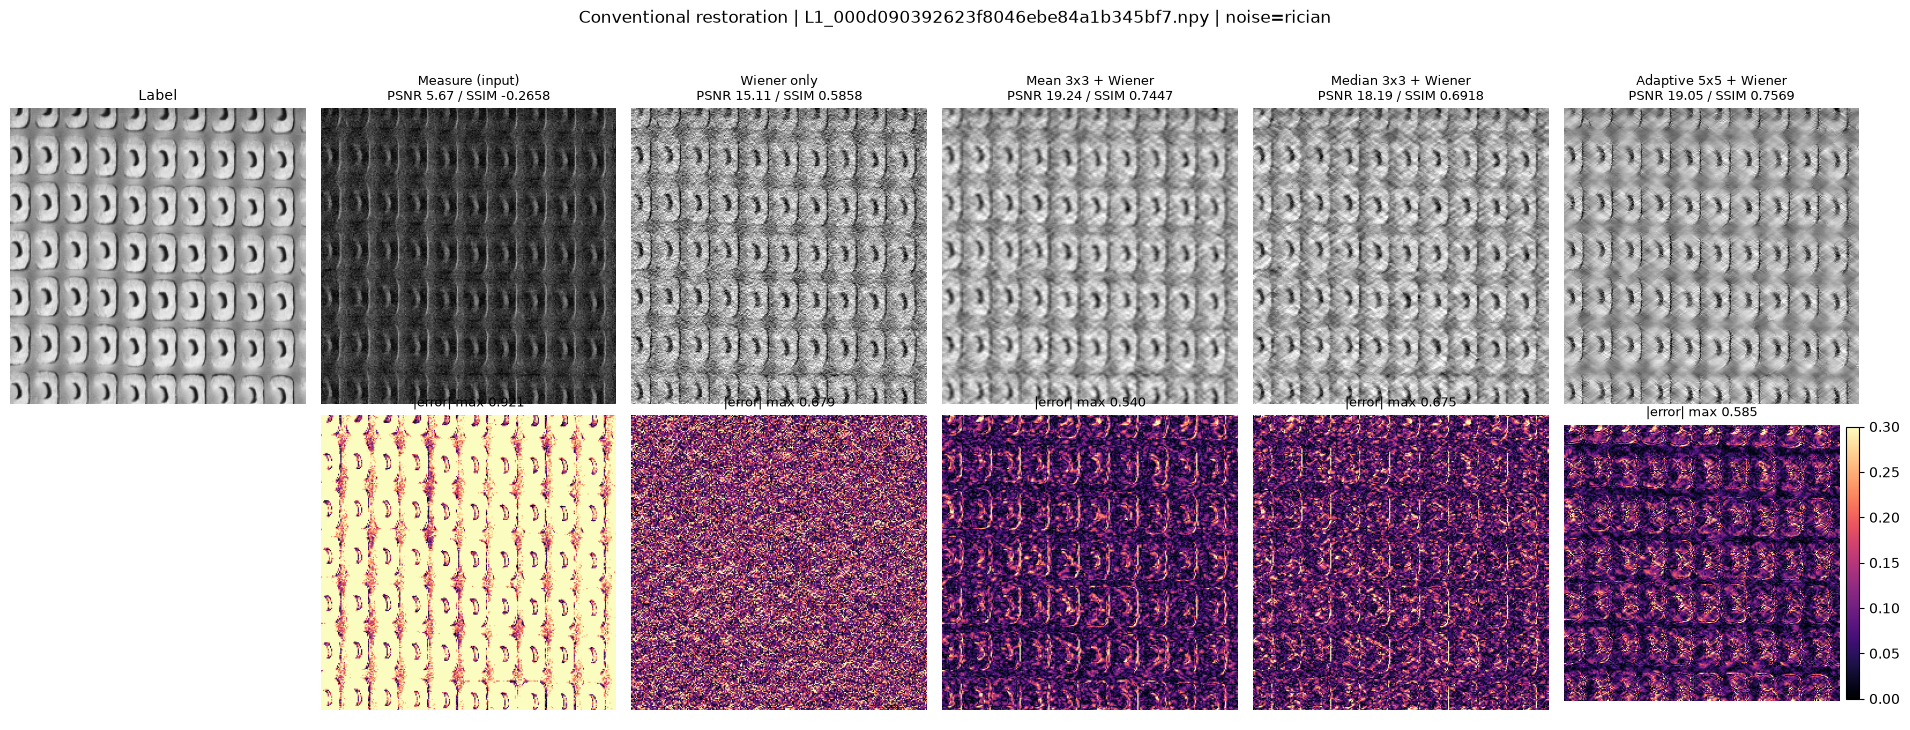

In [ ]:
# 대표 sample 하나로 conventional 결과를 눈으로 확인한다
_label, _measure, _blur, _noisy_label, _name = test_dataset[SAMPLE_IDX]
_lab_t = _label[None].to(config.device)
_mea_t = _measure[None].to(config.device)
with torch.no_grad():
    _preds = conventional_predict(_mea_t)

lab = _lab_t.cpu().numpy().squeeze()
n_col = 1 + len(CONV_METHODS)
fig, axes = plt.subplots(2, n_col, figsize=(3.2 * n_col, 7.4))
axes[0, 0].imshow(lab, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Label", fontsize=10)
axes[0, 0].axis("off")
axes[1, 0].axis("off")

for c, key in enumerate(CONV_METHODS):
    img = _preds[key].cpu().numpy().squeeze()
    p = calculate_psnr(_preds[key], _lab_t).item()
    s = calculate_ssim(_preds[key], _lab_t).item()
    err = np.abs(img - lab)
    axes[0, c + 1].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[0, c + 1].set_title(f"{CONV_LABEL[key]}\nPSNR {p:.2f} / SSIM {s:.4f}", fontsize=9)
    axes[0, c + 1].axis("off")
    im = axes[1, c + 1].imshow(err, cmap="magma", vmin=0, vmax=0.3)
    axes[1, c + 1].set_title(f"|error| max {err.max():.3f}", fontsize=9)
    axes[1, c + 1].axis("off")
fig.colorbar(im, ax=axes[1, -1], fraction=0.046, pad=0.02)
fig.suptitle(f"Conventional restoration | {_name} | noise={TEST_NOISE_META.get(_name, {}).get('noise_type', '?')}", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## 4. Methods using network

공통 building block 은 `train_deconvolution_example.ipynb` 의 U-Net,
`train_denoising_example.ipynb` 의 DnCNN 을 그대로 쓴다.

| | 방법 | 설명 |
|---|---|---|
| **A** | End2End U-Net | measure -> label 을 그냥 U-Net 으로 회귀 |
| **B** | DnCNN denoise + Wiener deconvolution | measurement domain 에서 noise 만 학습으로 제거하고, deconvolution 은 Wiener filter |

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_chans: int, out_chans: int) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_chans, out_chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_chans),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_chans, out_chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_chans),
            nn.SiLU(inplace=True),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.layers(x)


def create_down_sample_layers(in_chans: int, chans: int, num_pool_layers: int) -> nn.ModuleList:
    layers = nn.ModuleList([ConvBlock(in_chans, chans)])
    ch = chans
    for _ in range(num_pool_layers - 1):
        layers.append(ConvBlock(ch, ch * 2))
        ch *= 2
    return layers


def create_up_sample_layers(chans: int, num_pool_layers: int) -> nn.ModuleList:
    layers = nn.ModuleList()
    ch = chans * (2 ** (num_pool_layers - 1))
    for _ in range(num_pool_layers - 1):
        layers.append(ConvBlock(ch * 2, ch // 2))
        ch //= 2
    layers.append(ConvBlock(ch * 2, ch))
    return layers


class Unet(nn.Module):
    def __init__(self, in_chans: int = 1, out_chans: int = 1, chans: int = 32, num_pool_layers: int = 4) -> None:
        super().__init__()
        self.in_chans = in_chans
        self.out_chans = out_chans
        self.num_pool_layers = num_pool_layers

        self.down_sample_layers = create_down_sample_layers(in_chans, chans, num_pool_layers)
        self.bottleneck_conv = ConvBlock(chans * (2 ** (num_pool_layers - 1)), chans * (2 ** (num_pool_layers - 1)))
        self.up_sample_layers = create_up_sample_layers(chans, num_pool_layers)
        self.final_conv = nn.Sequential(
            nn.Conv2d(chans, chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, chans),
            nn.SiLU(inplace=True),
            nn.Conv2d(chans, out_chans, kernel_size=1, padding=0),
        )

    def forward(self, x: Tensor) -> Tensor:
        stack = []
        output = x
        for layer in self.down_sample_layers:
            output = layer(output)
            stack.append(output)
            output = functional.max_pool2d(output, kernel_size=2)

        output = self.bottleneck_conv(output)

        for layer in self.up_sample_layers:
            downsampled_output = stack.pop()
            output = functional.interpolate(
                output, size=downsampled_output.shape[-2:], mode="bilinear", align_corners=False
            )
            output = torch.cat([output, downsampled_output], dim=1)
            output = layer(output)

        return self.final_conv(output)


class DnCNN(nn.Module):
    def __init__(self, channels: int, num_of_layers: int, kernel_size: int, padding: int, features: int) -> None:
        super().__init__()
        layers: list[nn.Module] = [
            nn.Conv2d(channels, features, kernel_size=kernel_size, padding=padding, bias=False),
            nn.SiLU(inplace=True),
        ]
        for _ in range(num_of_layers - 1):
            layers += [
                nn.Conv2d(features, features, kernel_size=kernel_size, padding=padding, bias=False),
                nn.GroupNorm(4, features),
                nn.SiLU(inplace=True),
            ]
        layers.append(nn.Conv2d(features, channels, kernel_size=kernel_size, padding=padding, bias=False))
        self.dncnn = nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        if x.dim() != 4:
            raise ValueError(f"Input tensor must be 4D, but got {x.dim()}D tensor.")
        return x + self.dncnn(x)

## 5. 학습

L40S **4장 (GPU 2,3,4,5)** 기준 실측 (학습 7,268장, GPU 연산 기준):

| 모델 | params | batch | 처리량 | epoch | 100 epoch | peak / GPU |
|---|---|---|---|---|---|---|
| A. U-Net (`chans 64`) | 13.43 M | 64 | 440 img/s | 16.5초 | 약 28분 | 7.4 GiB |
| B. DnCNN (`20층, 96 feat`) | 1.58 M | 64 | 140 img/s | 52.1초 | 약 87분 | 22.6 GiB |

### A. End2End 단순 U-Net

In [ ]:
RESULTS["unet_e2e"] = train_model(SPECS["unet_e2e"])
print("run dir:", RESULTS["unet_e2e"]["run_dir"])

2026-09-01 21:22:53 [INFO] ####################################################################################################
2026-09-01 21:22:53 [INFO] [A. End2End U-Net] run dir: /home/jaehyeon/samsung/logs_final/00000_unet_e2e
2026-09-01 21:22:53 [INFO]   key: unet_e2e
2026-09-01 21:22:53 [INFO]   name: A. End2End U-Net
2026-09-01 21:22:53 [INFO]   target: label
2026-09-01 21:22:53 [INFO]   clean_branch_prob: 0.5
2026-09-01 21:22:53 [INFO]   epochs: 100
2026-09-01 21:22:53 [INFO]   batch: 64
2026-09-01 21:22:53 [INFO]   lr: 0.0002
2026-09-01 21:22:53 [INFO]   lr_decay: 0.95
2026-09-01 21:22:53 [INFO]   lr_tol: 1
2026-09-01 21:22:53 [INFO]   loss_model: l2
2026-09-01 21:22:53 [INFO]   num_workers: 16
2026-09-01 21:22:53 [INFO]   valid_interval: 1
2026-09-01 21:22:53 [INFO]   early_stop_patience: 10
2026-09-01 21:22:53 [INFO]   valid_fig_max: 4
2026-09-01 21:22:53 [INFO]   max_train_images: None
2026-09-01 21:22:53 [INFO] train 7268 | valid 100
2026-09-01 21:22:54 [INFO] DataParalle

A. End2End U-Net:   0%|          | 0/100 [00:00<?, ?epoch/s]

  A. End2End U-Net train ep 1:   0%|          | 0/113 [00:00<?, ?batch/s]

2026-09-01 21:23:14 [INFO] 00h 00m 27s | loss: 4.3626e-02


  A. End2End U-Net valid ep 1:   0%|          | 0/100 [00:00<?, ?batch/s]

...

2026-09-01 21:58:35 [INFO] 00h 35m 49s | psnr: 2.5048e+01 + 4.067e+00
2026-09-01 21:58:35 [INFO] 00h 35m 49s | ssim: 7.5648e-01 + 1.558e-01
[A. End2End U-Net] ep 99/100 lr 1.38e-06 | loss 3.3608e-03 | val PSNR 25.048 SSIM 0.7565 | best 25.055 (ep 98, 1 ago) | 21s


  A. End2End U-Net train ep 100:   0%|          | 0/113 [00:00<?, ?batch/s]

2026-09-01 21:58:56 [INFO] 00h 36m 10s | loss: 3.3169e-03


  A. End2End U-Net valid ep 100:   0%|          | 0/100 [00:00<?, ?batch/s]

2026-09-01 21:58:57 [INFO] 00h 36m 10s | psnr: 2.5035e+01 + 4.042e+00
2026-09-01 21:58:57 [INFO] 00h 36m 10s | ssim: 7.5696e-01 + 1.550e-01
[A. End2End U-Net] ep 100/100 lr 1.31e-06 | loss 3.3169e-03 | val PSNR 25.035 SSIM 0.7570 | best 25.055 (ep 98, 2 ago) | 21s
2026-09-01 21:59:00 [INFO] [A. End2End U-Net] done. best valid psnr 25.0547 at epoch 98
run dir: /home/jaehyeon/samsung/logs_final/00000_unet_e2e


### B. DnCNN denoiser (+ 뒤에서 Wiener deconvolution)

이 network 는 **label 이 아니라 noise 없는 dipole blur `Ax`** 를 맞추도록 학습한다.
deconvolution 은 학습이 아니라 Wiener filter 가 담당한다.

In [ ]:
RESULTS["dncnn"] = train_model(SPECS["dncnn"])
print("run dir:", RESULTS["dncnn"]["run_dir"])

2026-09-01 21:59:00 [INFO] ####################################################################################################
2026-09-01 21:59:00 [INFO] [B. DnCNN denoiser] run dir: /home/jaehyeon/samsung/logs_final/00001_dncnn
2026-09-01 21:59:00 [INFO]   key: dncnn
2026-09-01 21:59:00 [INFO]   name: B. DnCNN denoiser
2026-09-01 21:59:00 [INFO]   target: denoise_mixed
2026-09-01 21:59:00 [INFO]   clean_branch_prob: 0.5
2026-09-01 21:59:00 [INFO]   epochs: 100
2026-09-01 21:59:00 [INFO]   batch: 64
2026-09-01 21:59:00 [INFO]   lr: 0.0002
2026-09-01 21:59:00 [INFO]   lr_decay: 0.95
2026-09-01 21:59:00 [INFO]   lr_tol: 1
2026-09-01 21:59:00 [INFO]   loss_model: l2
2026-09-01 21:59:00 [INFO]   num_workers: 16
2026-09-01 21:59:00 [INFO]   valid_interval: 1
2026-09-01 21:59:00 [INFO]   early_stop_patience: 10
2026-09-01 21:59:00 [INFO]   valid_fig_max: 4
2026-09-01 21:59:00 [INFO]   max_train_images: None
2026-09-01 21:59:00 [INFO] train 7268 | valid 100
2026-09-01 21:59:00 [INFO] DataPar

B. DnCNN denoiser:   0%|          | 0/100 [00:00<?, ?epoch/s]

  B. DnCNN denoiser train ep 1:   0%|          | 0/113 [00:05<?, ?batch/s]

2026-09-01 21:59:59 [INFO] 00h 37m 13s | loss: 1.5936e-02


  B. DnCNN denoiser valid ep 1:   0%|          | 0/100 [00:00<?, ?batch/s]

...

  B. DnCNN denoiser train ep 69:   0%|          | 0/113 [00:00<?, ?batch/s]

2026-09-01 23:06:02 [INFO] 01h 43m 16s | loss: 7.1843e-04


  B. DnCNN denoiser valid ep 69:   0%|          | 0/100 [00:00<?, ?batch/s]

2026-09-01 23:06:05 [INFO] 01h 43m 18s | psnr_dipole: 2.7623e+01 + 7.216e+00
2026-09-01 23:06:05 [INFO] 01h 43m 18s | ssim_dipole: 8.6525e-01 + 1.333e-01
2026-09-01 23:06:05 [INFO] 01h 43m 18s | psnr_clean: 3.2312e+01 + 4.525e+00
2026-09-01 23:06:05 [INFO] 01h 43m 18s | ssim_clean: 8.9586e-01 + 9.578e-02
[B. DnCNN denoiser] ep 69/100 lr 6.43e-06 | loss 7.1843e-04 | val PSNR 27.623 SSIM 0.8652 | best 27.834 (ep 67, 2 ago) | 57s


  B. DnCNN denoiser train ep 70:   0%|          | 0/113 [00:00<?, ?batch/s]

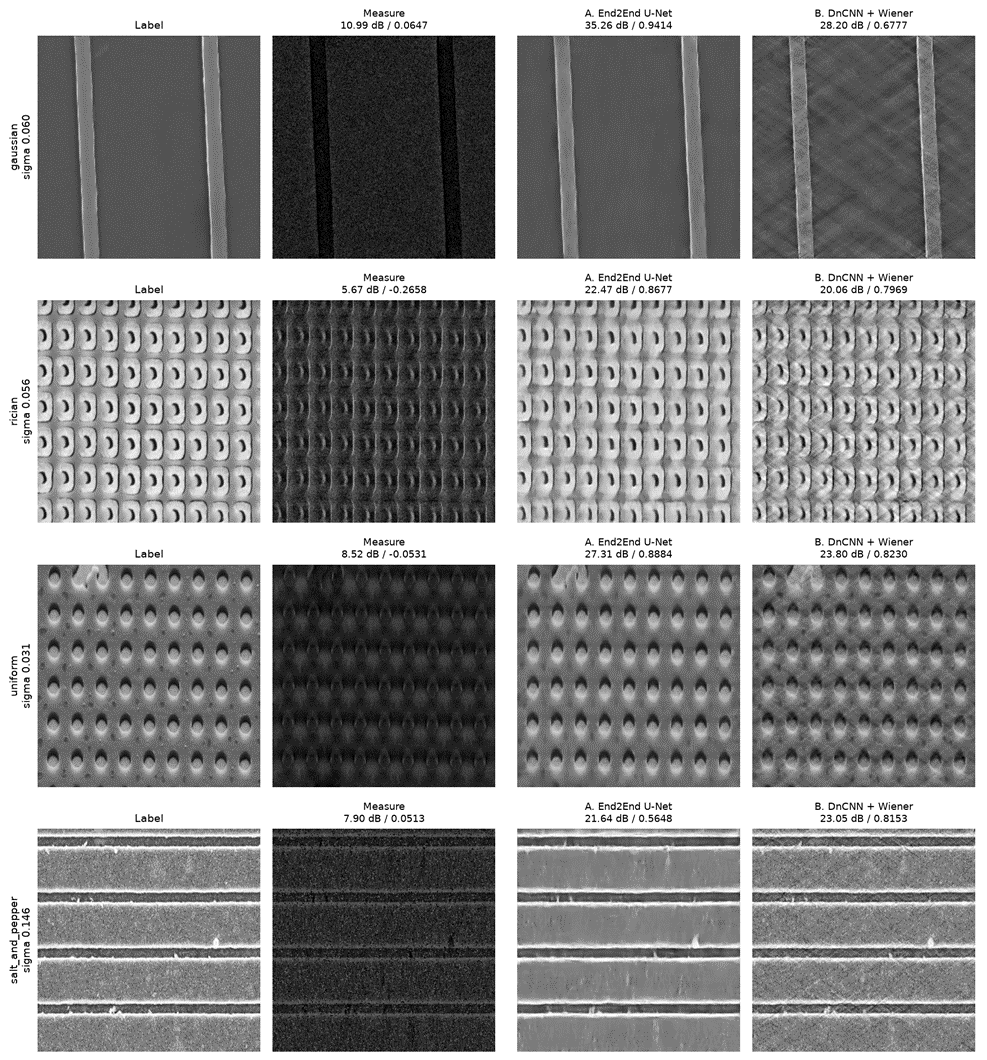